# Ejercicio. Diabetes

> ### Se desea determinar la progresión de la enfermedad mediante un modelo lineal, con base en su IMC.


### 1. Carga y preparación de datos

Utilizamos el set de datos de la librería de Scikit learn “diabetes”

In [13]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = load_diabetes()
print(df.data.shape)
df.feature_names

(442, 10)


['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [15]:
x = df.data[:, 2].reshape(-1, 1)
y = df.target.reshape(-1, 1)

In [16]:
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.3, random_state=0)

### 2. Implementar el modelo de regresión lineal.

In [17]:
regressor = LinearRegression()
regressor.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
y_pred = regressor.predict(X_test)

### 3. Evaluar el modelo

In [19]:
print("Mean squared error: %.2f" % mean_squared_error(Y_test, y_pred))
print("Coefficient of determination: %.2f" % regressor.score(X_test, Y_test))

Mean squared error: 3921.37
Coefficient of determination: 0.23


### 4. Graficar los resultados

Text(0.5, 0.98, 'Linear regression model')

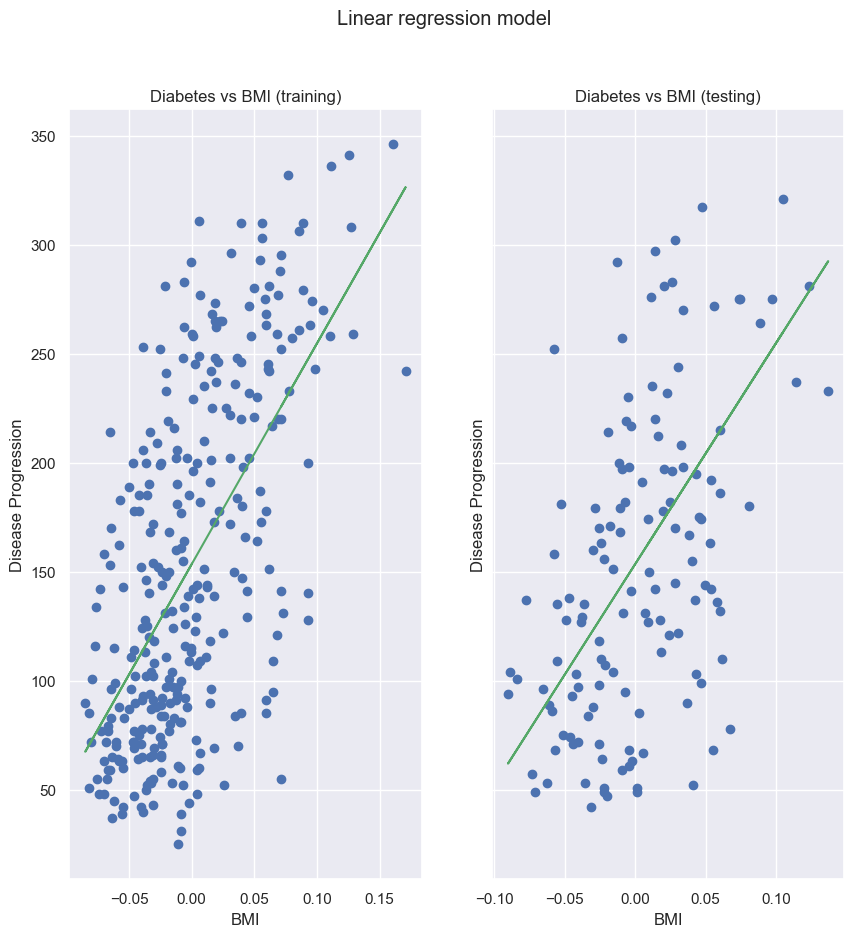

In [20]:
sns.set_theme()
fig, ax = plt.subplots(1, 2, figsize=(10, 10), sharey=True)
ax[0].scatter(X_train, Y_train)
ax[0].plot(X_train, regressor.predict(X_train), c='g')
ax[0].set_title('Diabetes vs BMI (training)')
ax[0].set_xlabel('BMI')
ax[0].set_ylabel('Disease Progression')
ax[1].scatter(X_test, Y_test)
ax[1].plot(X_test, regressor.predict(X_test), c='g')
ax[1].set_title('Diabetes vs BMI (testing)')
ax[1].set_xlabel('BMI')
ax[1].set_ylabel('Disease Progression')
plt.suptitle('Linear regression model')

## Método alterno

In [21]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

diabetes = load_diabetes()

x2 = diabetes.data[:, 2].reshape(-1, 1)
y2 = diabetes.target

# últimas 20 muestras para test
x2_train = x2[:-20]
x2_test  = x2[-20:]
y2_train = y2[:-20]
y2_test  = y2[-20:]

regressor = LinearRegression()
regressor.fit(x2_train, y2_train)
y2_pred = regressor.predict(x2_test)

# Evaluar
print("Mean squared error: %.2f" % mean_squared_error(y2_test, y2_pred))
print("Coefficient of determination: %.2f" % r2_score(y2_test, y2_pred))


Mean squared error: 2548.07
Coefficient of determination: 0.47


Text(0.5, 0.98, 'Linear Regression')

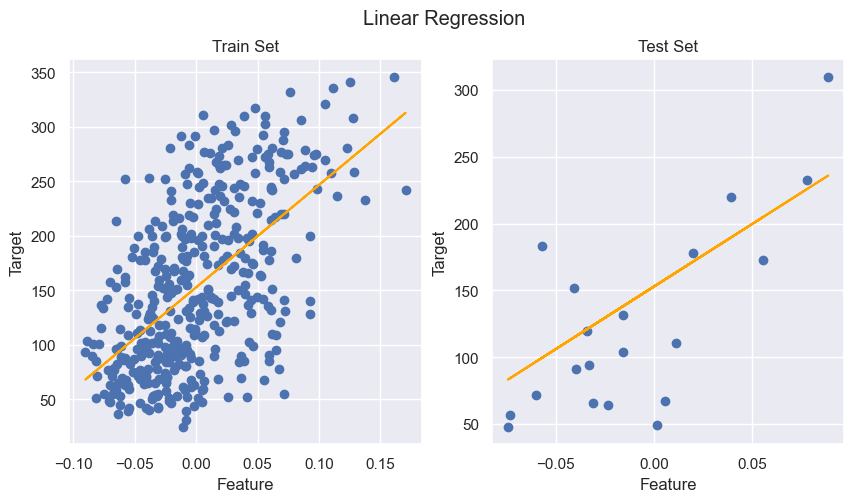

In [23]:
fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].scatter(x2_train, y2_train)
ax[0].plot(x2_train,regressor.predict(x2_train), c='orange')
ax[0].set_title("Train Set")
ax[0].set_xlabel("Feature")
ax[0].set_ylabel("Target")
ax[1].scatter(x2_test, y2_test)
ax[1].plot(x2_test, regressor.predict(x2_test), c="orange")
ax[1].set_title("Test Set")
ax[1].set_xlabel("Feature")
ax[1].set_ylabel("Target")
plt.suptitle("Linear Regression")

### 5. Escribir una conclusión

Para hacer la práctica usamos un modelo de regresión lineal en el que buscabamos comparar el bmi y la progresión de la enfermedad. Utilizamos el error cuadrático medio y el coeficiente de determinación para medir la eficacia. Podemos observar que usando el metodo 2 es más ajustado y reduce el error de predicción.